In [ ]:
from pathlib import Path
import yaml
filepath = "/mnt/atlas02/users/leoli/scarf/metadata/calib"

runs = [
    's20ns_mw5',  's20ns_mw7',
    's30ns_mw3',  's30ns_mw5',  's30ns_mw7',
    's40ns_mw1',  's40ns_mw3',  's40ns_mw5',  's40ns_mw7',
    's50ns_mw1',  's50ns_mw3',  's50ns_mw5',  's50ns_mw7',
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7',
    's300ns_mw1', 's300ns_mw3', 's300ns_mw5', 's300ns_mw7','s300ns_mw15',
    's500ns_mw1', 's500ns_mw3', 's500ns_mw5', 's500ns_mw7','s500ns_mw15',
    's700ns_mw1', 's700ns_mw3', 's700ns_mw5', 's700ns_mw7','s700ns_mw15',
    's1000ns_mw1',  's1000ns_mw3',  's1000ns_mw5',  's1000ns_mw7','s1000ns_mw15',
    's2000ns_mw3',  's2000ns_mw5',  's2000ns_mw7',
]
test_run = "s200ns_mw5"
yaml_path = Path(filepath) / f"{test_run}/cal/p05/r057/sp01-p05-r057-cal-hpge-calib.yaml"

with open(yaml_path, "r") as f:
    cfg = yaml.safe_load(f)

cut_value_90 = cfg["ch002"]["A_max_mw_o_E_fix"]['AoE_cal_dicts']['AoE_Low_Cut']['parameters']['a']
sfs = cfg["ch002"]["A_max_mw_o_E_fix"]['AoE_low_side_sfs']['sf']
sf_val_dep,sf_val_sep,sf_val_fep= sfs['1592.5'],sfs['2103.53'],sfs['2614.5']
print(cut_value_90,sf_val_dep,sf_val_sep,sf_val_fep)

-1.04 90.0215404465 7.5826791892 11.4007349573


In [ ]:
sfs = cfg["ch002"]["A_max_mw_o_E_fix"]['AoE_low_side_sfs']['sf']
sf_val_sep,sf_val_dep,sf_val_fep= sfs['1592.5'],sfs['2103.53'],sfs['2614.5']

In [ ]:
survival_db = {}
for run in runs:
    yaml_path = Path(filepath) / f"{run}/cal/p05/r057/sp01-p05-r057-cal-hpge-calib.yaml"
    with open(yaml_path, "r") as f:
        cfg = yaml.safe_load(f)

    cut_value_90 = cfg["ch002"]["A_max_mw_o_E_fix"]['AoE_cal_dicts']['AoE_Low_Cut']['parameters']['a']
    sfs = cfg["ch002"]["A_max_mw_o_E_fix"]['AoE_low_side_sfs']['sf']
    sfs_err = cfg["ch002"]["A_max_mw_o_E_fix"]['AoE_low_side_sfs']['sf_err']
    # sf_val_dep,sf_val_sep,sf_val_fep= sfs['1592.5'],sfs['2103.53'],sfs['2614.5']
    sf_val_dep = sfs["1592.5"]
    sf_val_sep = sfs["2103.53"]
    sf_val_fep = sfs["2614.5"]
    
    sf_val_dep_err = sfs_err['1592.5']
    sf_val_sep_err = sfs_err["2103.53"]
    sf_val_fep_err = sfs_err["2614.5"]

    survival_db[run] = {
        "cut_value_90": cut_value_90,
        "dep_sf": sf_val_dep,
        "sep_sf": sf_val_sep,
        "fep_sf": sf_val_fep,
        'dep_sf_err': sf_val_dep_err,
        'sep_sf_err': sf_val_sep_err,
        'fep_sf_err': sf_val_fep_err,
    }

In [4]:
import numpy as np
from matplotlib import pyplot as plt
def plot_heatmap(databook):

    window = ['20',"30","40","50","60", "100", "200", "300", "500", "700"]
    mw = ["mw15", "mw7", "mw5", "mw3", "mw1"]

    shape = (len(mw), len(window))

    # NaN means that the configuration is unavailable
    dep_sf_matrix = np.full(shape, np.nan)
    sep_sf_matrix = np.full(shape, np.nan)
    fep_sf_matrix = np.full(shape, np.nan)

    dep_err_matrix = np.full(shape, np.nan)
    sep_err_matrix = np.full(shape, np.nan)
    fep_err_matrix = np.full(shape, np.nan)

    for j, w in enumerate(window):
        for i, m in enumerate(mw):
            run_name = f"s{w}ns_{m}"

            # Leave the cell as NaN if the run is missing
            if run_name not in databook:
                print(f"Missing: {run_name}")
                continue

            run_data = databook[run_name]

            dep_sf_matrix[i, j] = run_data.get("dep_sf", np.nan)
            sep_sf_matrix[i, j] = run_data.get("sep_sf", np.nan)
            fep_sf_matrix[i, j] = run_data.get("fep_sf", np.nan)

            dep_err_matrix[i, j] = run_data.get("dep_sf_err", np.nan)
            sep_err_matrix[i, j] = run_data.get("sep_sf_err", np.nan)
            fep_err_matrix[i, j] = run_data.get("fep_sf_err", np.nan)

    matrices = [
        (
            dep_sf_matrix,
            dep_err_matrix,
            "DEP Survival Fraction after low A/E cut",
        ),
        (
            sep_sf_matrix,
            sep_err_matrix,
            "SEP Survival Fraction after low A/E cut",
        ),
        (
            fep_sf_matrix,
            fep_err_matrix,
            "FEP Survival Fraction after low A/E cut",
        ),
    ]

    # Make missing/NaN cells grey
    cmap = plt.colormaps["viridis"].copy()
    cmap.set_bad(color="lightgray")

    for matrix, err_matrix, title in matrices:
        fig, ax = plt.subplots(figsize=(7, 5))

        vmax = 100 if "DEP" in title else 15

        # Mask NaN values so set_bad() applies
        masked_matrix = np.ma.masked_invalid(matrix)

        im = ax.imshow(
            masked_matrix,
            vmin=0,
            vmax=vmax,
            cmap=cmap,
            aspect="auto",
        )

        ax.set_title(title)
        ax.set_xlabel("Window [ns]")
        ax.set_ylabel("Moving-average iterations")

        ax.set_xticks(np.arange(len(window)))
        ax.set_xticklabels(window)

        ax.set_yticks(np.arange(len(mw)))
        ax.set_yticklabels(mw)

        for i in range(len(mw)):
            for j in range(len(window)):

                if np.isnan(matrix[i, j]):
                    ax.text(
                        j,
                        i,
                        "no data",
                        ha="center",
                        va="center",
                        color="dimgray",
                        fontsize=9,
                    )
                    continue

                text_str = (
                    f"{matrix[i, j]:.1f}%\n"
                    f"±{err_matrix[i, j]:.1f}%"
                )

                # Choose text color based on the actual color scale
                text_color = (
                    "white"
                    if im.norm(matrix[i, j]) < 0.65
                    else "black"
                )

                ax.text(
                    j,
                    i,
                    text_str,
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=9,
                )

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.tight_layout()
        plt.show()
# def plot_heatmap(databook):

#     window = ["60", "100", "200",'300','500','700']
#     mw = ['mw15',"mw7", "mw5", "mw3", "mw1"]

#     # Matrices for the survival fraction values
#     dep_sf_matrix = np.zeros((len(mw), len(window)))
#     sep_sf_matrix = np.zeros((len(mw), len(window)))
#     fep_sf_matrix = np.zeros((len(mw), len(window)))

#     # Matrices for the associated errors
#     dep_err_matrix = np.zeros((len(mw), len(window)))
#     sep_err_matrix = np.zeros((len(mw), len(window)))
#     fep_err_matrix = np.zeros((len(mw), len(window)))

#     for j, w in enumerate(window):      # columns: window
#         for i, m in enumerate(mw):      # rows: mw
#             run_name = f"s{w}ns_{m}"
            
#             if run_name not in databook:
#                 print(f"Missing: {run_name}")
#                 continue
#             # Note: passing `databook` as the variable instead of the global `survival_db`
#             dep_sf_matrix[i, j] = databook[run_name]["dep_sf"]
#             sep_sf_matrix[i, j] = databook[run_name]["sep_sf"]
#             fep_sf_matrix[i, j] = databook[run_name]["fep_sf"]
            
#             # Extract the errors
#             dep_err_matrix[i, j] = databook[run_name]["dep_sf_err"]
#             sep_err_matrix[i, j] = databook[run_name]["sep_sf_err"]
#             fep_err_matrix[i, j] = databook[run_name]["fep_sf_err"]

#     # Combine values, errors, and titles to iterate through them
#     matrices = [
#         (dep_sf_matrix, dep_err_matrix, "DEP Survival Fraction after low A/E cut"),
#         (sep_sf_matrix, sep_err_matrix, "SEP Survival Fraction after low A/E cut"),
#         (fep_sf_matrix, fep_err_matrix, "FEP Survival Fraction after low A/E cut"),
#     ]

#     # Create a separate figure for each matrix
#     for matrix, err_matrix, title in matrices:
#         fig, ax = plt.subplots(figsize=(6, 5))
        
#         # You may want to adjust vmin and vmax depending on the specific plot, 
#         # as DEP is usually ~90% and SEP/FEP are much lower.
#         im = ax.imshow(matrix, vmin=0, vmax=100 if "DEP" in title else 15, cmap="viridis", aspect="auto")

#         ax.set_title(title)
#         ax.set_xlabel("window ns")
#         ax.set_ylabel("mw")

#         ax.set_xticks(np.arange(len(window)))
#         ax.set_xticklabels(window)

#         ax.set_yticks(np.arange(len(mw)))
#         ax.set_yticklabels(mw)

#         # Write the value and the error inside each box

#         for i in range(len(mw)):
#             for j in range(len(window)):

#                 if np.isnan(matrix[i, j]):
#                     ax.text(
#                         j,
#                         i,
#                         "N/A",
#                         ha="center",
#                         va="center",
#                         color="dimgray",
#                         fontsize=9,
#                     )
#                     continue

#                 text_str = (
#                     f"{matrix[i, j]:.1f}%\n"
#                     f"±{err_matrix[i, j]:.1f}%"
#                 )

#                 # Choose text color based on the actual color scale
#                 text_color = (
#                     "white"
#                     if im.norm(matrix[i, j]) < 0.65
#                     else "black"
#                 )

#                 ax.text(
#                     j,
#                     i,
#                     text_str,
#                     ha="center",
#                     va="center",
#                     color=text_color,
#                     fontsize=9,
#                 )

#         fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#         fig.tight_layout()
#         plt.show()

In [ ]:
# for run in runs:
#     print(run , survival_db[run]['cut_value_90'])

s20ns_mw5 -0.94
s20ns_mw7 -1.1
s30ns_mw3 -1.18
s30ns_mw5 -1.22
s30ns_mw7 -1.25
s40ns_mw1 -1.11
s40ns_mw3 -1.27
s40ns_mw5 -1.24
s40ns_mw7 -1.19
s50ns_mw1 -1.05
s50ns_mw3 -1.25
s50ns_mw5 -1.17
s50ns_mw7 -1.16
s100ns_mw1 -1.09
s100ns_mw3 -1.12
s100ns_mw5 -1.115
s100ns_mw7 -1.09
s200ns_mw1 -0.87
s200ns_mw3 -1.05
s200ns_mw5 -1.04
s200ns_mw7 -1.01
s60ns_mw1 -0.95
s60ns_mw3 -1.195
s60ns_mw5 -1.15
s60ns_mw7 -1.13
s300ns_mw1 -0.84
s300ns_mw3 -0.97
s300ns_mw5 -0.96
s300ns_mw7 -0.94
s300ns_mw15 -0.86
s500ns_mw1 -0.89
s500ns_mw3 -0.95
s500ns_mw5 -0.86
s500ns_mw7 -0.82
s500ns_mw15 -0.72
s700ns_mw1 -0.83
s700ns_mw3 -0.82
s700ns_mw5 -0.75
s700ns_mw7 -0.71
s700ns_mw15 -0.74
s1000ns_mw1 -0.9
s1000ns_mw3 -0.73
s1000ns_mw5 -0.71
s1000ns_mw7 -0.75
s1000ns_mw15 -1.01
s2000ns_mw3 -0.77
s2000ns_mw5 -0.81
s2000ns_mw7 -1.02


Missing: s20ns_mw15
Missing: s20ns_mw3
Missing: s20ns_mw1
Missing: s30ns_mw15
Missing: s30ns_mw1
Missing: s40ns_mw15
Missing: s50ns_mw15
Missing: s60ns_mw15
Missing: s100ns_mw15
Missing: s200ns_mw15


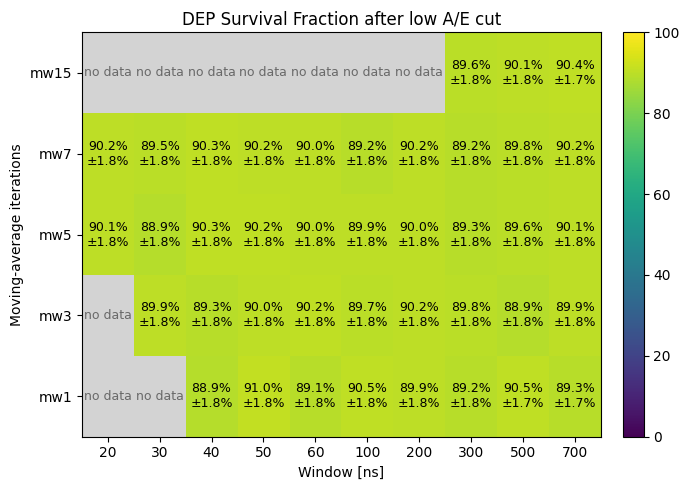

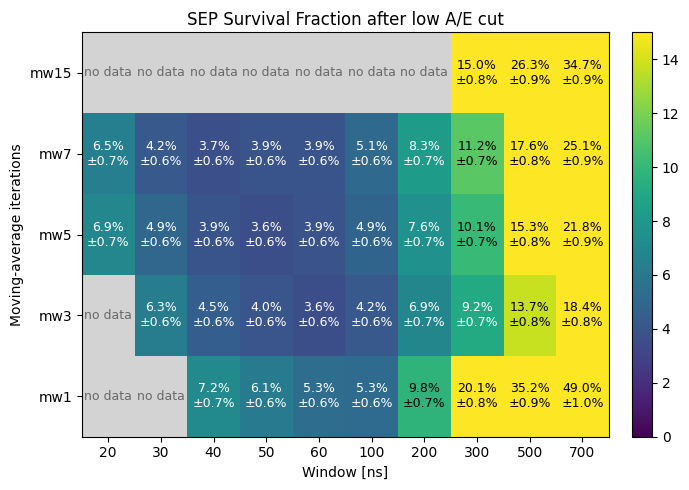

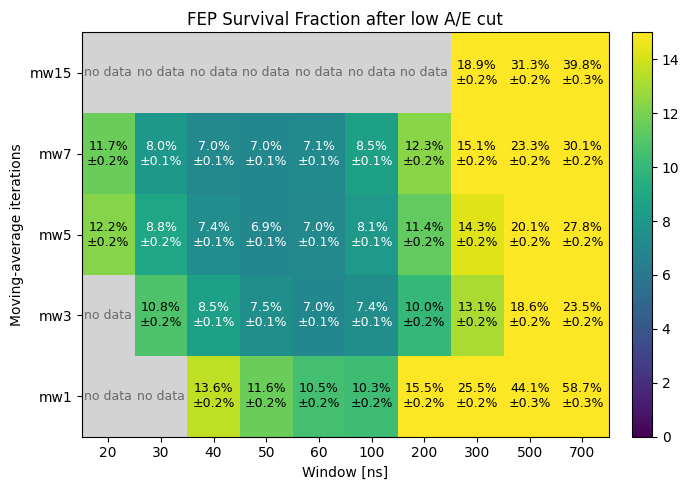

In [6]:
plot_heatmap(survival_db)

In [7]:
for run in runs:
    print(f"{survival_db[run]['cut_value_90']}   "+run)

-0.94   s20ns_mw5
-1.1   s20ns_mw7
-1.18   s30ns_mw3
-1.22   s30ns_mw5
-1.25   s30ns_mw7
-1.11   s40ns_mw1
-1.27   s40ns_mw3
-1.24   s40ns_mw5
-1.19   s40ns_mw7
-1.05   s50ns_mw1
-1.25   s50ns_mw3
-1.17   s50ns_mw5
-1.16   s50ns_mw7
-1.09   s100ns_mw1
-1.12   s100ns_mw3
-1.115   s100ns_mw5
-1.09   s100ns_mw7
-0.87   s200ns_mw1
-1.05   s200ns_mw3
-1.04   s200ns_mw5
-1.01   s200ns_mw7
-0.95   s60ns_mw1
-1.195   s60ns_mw3
-1.15   s60ns_mw5
-1.13   s60ns_mw7
-0.84   s300ns_mw1
-0.97   s300ns_mw3
-0.96   s300ns_mw5
-0.94   s300ns_mw7
-0.86   s300ns_mw15
-0.89   s500ns_mw1
-0.95   s500ns_mw3
-0.86   s500ns_mw5
-0.82   s500ns_mw7
-0.72   s500ns_mw15
-0.83   s700ns_mw1
-0.82   s700ns_mw3
-0.75   s700ns_mw5
-0.71   s700ns_mw7
-0.74   s700ns_mw15
-0.9   s1000ns_mw1
-0.73   s1000ns_mw3
-0.71   s1000ns_mw5
-0.75   s1000ns_mw7
-1.01   s1000ns_mw15
-0.77   s2000ns_mw3
-0.81   s2000ns_mw5
-1.02   s2000ns_mw7


In [8]:
import pickle 
with open("/mnt/atlas02/users/leoli/AoverE_analysis/SEP_analysis/survival_db_yaml.pkl", "wb") as f:
    pickle.dump(survival_db, f)